In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import json
import os

In [4]:
import os

print("Current Folder:")
print(os.getcwd())

Current Folder:
c:\Users\Sankeerthana\Desktop\Internship\zelbytes-yield-forecasting\notebooks


In [5]:
import os

print(os.listdir("."))

['.gitkeep', 'task3_eda.ipynb', 'task4_feature_engineering.ipynb', 'task5_linear_regression.ipynb']


In [7]:
import os

print(os.getcwd())

c:\Users\Sankeerthana\Desktop\Internship\zelbytes-yield-forecasting\notebooks


In [8]:
import os

print(os.listdir(".."))

['.git', 'data', 'generate_data.py', 'models', 'notebooks', 'README.md', 'reports', 'smoke_test.py', 'src', 'venv']


In [9]:
import os

print(os.listdir("../data"))

['interim', 'processed', 'raw']


In [10]:
print(os.listdir("../data/raw"))

['.gitkeep', 'interim', 'polyhouse_sensors.csv']


In [11]:
print(os.listdir("../data/interim"))

['01_loaded.parquet']


In [12]:
df = pd.read_csv("../data/raw/polyhouse_sensors.csv")

In [13]:
df.head()

,timestamp,temperature,humidity,co2,yield_kg
0,2026-06-01 08:00:00,25.7,79.0,929.0,12.34
1,2026-06-01 09:00:00,24.8,83.0,945.0,12.55
2,2026-06-01 10:00:00,26.0,84.0,987.0,13.60
3,2026-06-01 11:00:00,27.3,82.0,984.0,13.49
4,2026-06-01 12:00:00,24.6,84.0,790.0,12.98


In [14]:
df.shape

(100, 5)

In [15]:
df.columns

Index(['timestamp', 'temperature', 'humidity', 'co2', 'yield_kg'], dtype='str')

In [16]:
X = df[['temperature', 'humidity', 'co2']]
y = df['yield_kg']

In [17]:
print(X.head())

   temperature  humidity    co2
0         25.7      79.0  929.0
1         24.8      83.0  945.0
2         26.0      84.0  987.0
3         27.3      82.0  984.0
4         24.6      84.0  790.0


In [18]:
print(y.head())

0    12.34
1    12.55
2    13.60
3    13.49
4    12.98
Name: yield_kg, dtype: float64


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (80, 3)
X_test : (20, 3)
y_train: (80,)
y_test : (20,)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
print(X_train_scaled[:5])

[[ 1.13247767 -0.82361738 -0.50371661]
 [-0.44563848 -0.82361738  0.16571069]
 [-1.09123145 -1.08508321 -0.02085101]
 [-0.01524317 -1.60801488  0.36324662]
 [-0.58910358 -0.82361738  0.03402008]]


In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-0.16,-0.06, 0.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,13.14
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[9.77,8.92,8.06]"


In [24]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/linear_regression.joblib")

['../models/linear_regression.joblib']

In [25]:
import os

os.listdir("../models")

['.gitkeep', 'linear_regression.joblib', 'scaler.joblib']

In [26]:
y_train_pred = model.predict(X_train_scaled)

In [27]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [28]:
print(y_test_pred[:5])

[13.16970909 13.01947277 13.14150317 13.19845672 13.34099295]


In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_test_pred)

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_test_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.49386110572816655
RMSE: 0.5733907161996653
R²  : -0.4740401351027772


In [30]:
import json
import os

metrics = {
    "MAE": float(mae),
    "RMSE": float(rmse),
    "R2": float(r2)
}

os.makedirs("../reports", exist_ok=True)

with open("../reports/linear_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [32]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,temperature,-0.155611
1,humidity,-0.055838
2,co2,0.012479


In [33]:
residuals = y_test - y_test_pred

print(residuals.head())


83   -0.589709
53   -0.149473
70   -0.121503
45   -0.008457
44   -0.720993
Name: yield_kg, dtype: float64


In [34]:
import os

os.makedirs("../reports/figures", exist_ok=True)

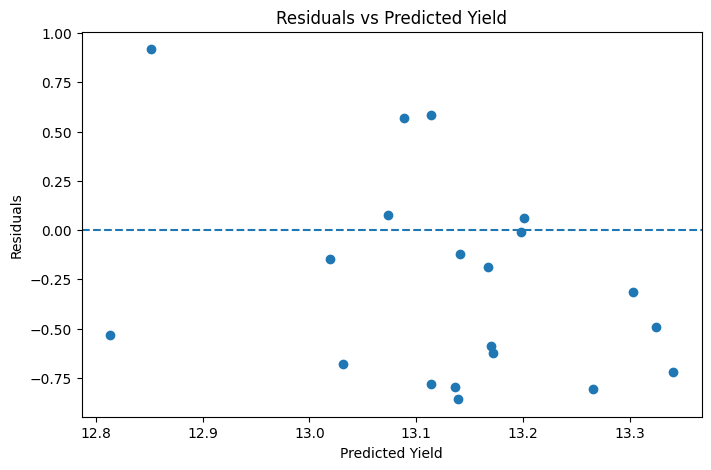

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test_pred, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Yield")

plt.savefig(
    "../reports/figures/residuals_vs_predicted_linear.png",
    bbox_inches="tight"
)

plt.show()

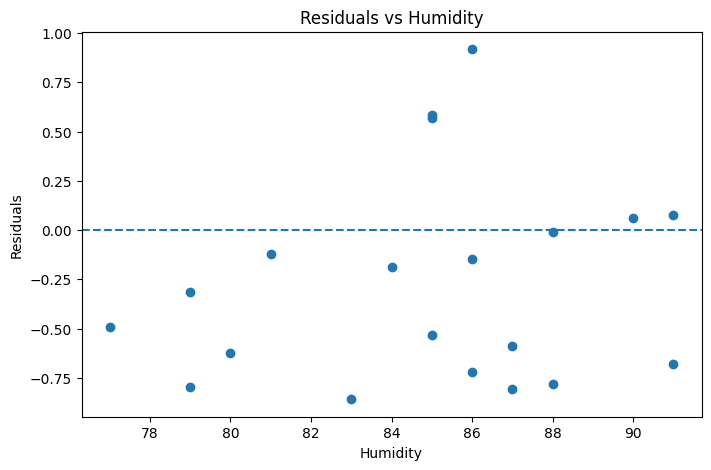

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test["humidity"], residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Humidity")
plt.ylabel("Residuals")
plt.title("Residuals vs Humidity")

plt.savefig(
    "../reports/figures/residuals_vs_humidity_linear.png",
    bbox_inches="tight"
)

plt.show()

In [37]:
residuals = y_test - y_test_pred

In [38]:
import json

metrics = {
    "MAE": float(mae),
    "RMSE": float(rmse),
    "R2": float(r2)
}

with open("../reports/linear_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved.")

Metrics saved.
